In [1]:
import numpy as np                          # numeric operations
import pandas as pd                         # data loading and manipulation
import matplotlib.pyplot as plt             # plotting
import seaborn as sns                       # nicer plot styling
from sklearn.cluster import KMeans          # KMeans clustering algorithm


In [2]:
customer_data = pd.read_csv("Mall_Customers.csv")  # load the mall customers dataset

In [3]:
customer_data.head(5)  # preview the first 5 rows

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
customer_data.shape  # (rows, columns) of the dataset

(200, 5)

In [5]:
customer_data.describe()  # summary stats (mean, std, min, max) for numeric columns

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
customer_data.info()  # column dtypes and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
customer_data.isnull().sum()  # count missing values per column

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
X = customer_data.iloc[:, [3, 4]].values  # select Annual Income (col 3) and Spending Score (col 4) as clustering features

In [9]:
print(X)  # show the raw feature array

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [10]:
wcss = []  # will hold within-cluster sum of squares for each k

for i in range(1, 11):                                              # try k = 1 to 10 clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)  # init a KMeans model with k clusters
    kmeans.fit(X)                                                     # fit the model on the income/spending data
    wcss.append(kmeans.inertia_)                                      # record the inertia (WCSS) for this k


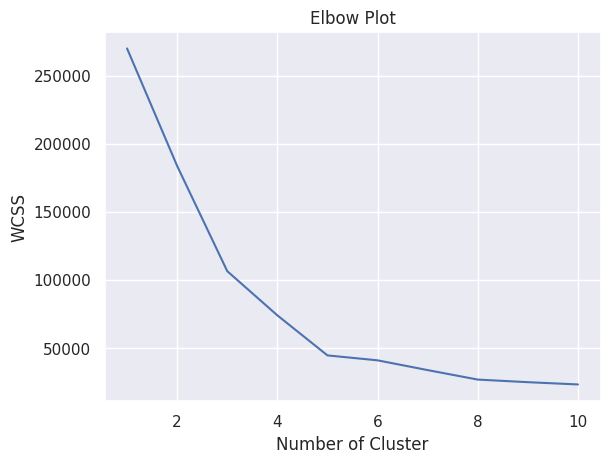

In [11]:
sns.set()                                    # apply seaborn's default styling
plt.plot(range(1, 11), wcss)                 # plot WCSS against number of clusters
plt.title("Elbow Plot")                      # chart title
plt.xlabel("Number of Cluster")              # x-axis label
plt.ylabel("WCSS")                           # y-axis label (within-cluster sum of squares)
plt.show()                                   # display the elbow plot


The elbow plot bends around **k = 5**, so we pick 5 clusters for the final model.

In [12]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)  # final model with the chosen k=5 clusters

In [13]:
print(X)  # sanity check: confirm the feature array used for clustering

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [14]:
y = kmeans.fit_predict(X)  # fit the model and assign each customer to one of the 5 clusters

In [15]:
print(y)  # cluster label (0-4) assigned to each customer

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


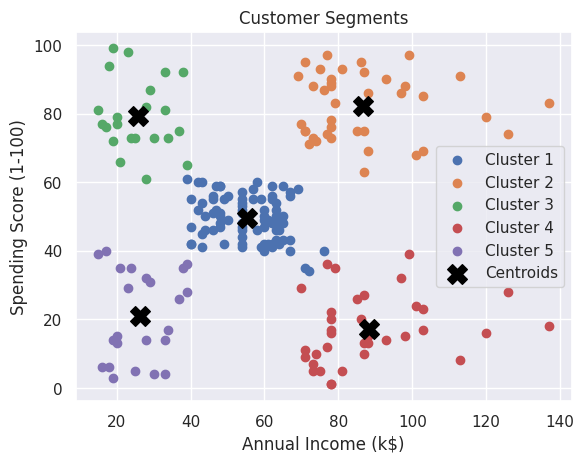

In [16]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Cluster 1')  # plot customers in cluster 0
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Cluster 2')  # plot customers in cluster 1
plt.scatter(X[y == 2, 0], X[y == 2, 1], label='Cluster 3')  # plot customers in cluster 2
plt.scatter(X[y == 3, 0], X[y == 3, 1], label='Cluster 4')  # plot customers in cluster 3
plt.scatter(X[y == 4, 0], X[y == 4, 1], label='Cluster 5')  # plot customers in cluster 4

plt.scatter(kmeans.cluster_centers_[:, 0],                   # x-coords of the 5 cluster centroids
            kmeans.cluster_centers_[:, 1],                   # y-coords of the 5 cluster centroids
            s=200, c='black', marker='X', label='Centroids')  # mark centroids as black X's

plt.xlabel('Annual Income (k$)')  # x-axis label
plt.ylabel('Spending Score (1-100)')  # y-axis label
plt.title('Customer Segments')  # chart title
plt.legend()                                                 # show cluster legend
plt.show()                                                   # display the final cluster plot
